In [82]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


# 📊 Étape 3 : Visualisation Multidimensionnelle

Cette étape correspond au quatrième chapitre du cours. L'objectif est de concevoir des représentations visuelles premium pour identifier des tendances et insights clés à l'aide de différents outils de bisualisation.

### 1. Préparation de l'environnement

In [83]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Librairies de visualisation prêtes !")

Librairies de visualisation prêtes !


### 2. Chargement du dataset enrichi

In [84]:
df = pd.read_csv('../data/processed/cleaned_data_sample.csv')
df.head()

,Date,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Payment Method,Completed
0,2024-01-01 00:19:34,0,0,18,8.259587,14.125453,216.059132,45.239282,0,True
1,2024-01-01 01:35:18,1,1,30,21.469140,15.482024,200.445703,30.077034,1,True
2,2024-01-01 01:53:01,1,2,114,19.530077,28.163239,331.550225,35.884651,2,True
3,2024-01-01 03:59:29,1,3,30,9.823459,43.016231,410.514751,32.698439,0,True
4,2024-01-01 04:00:07,2,4,116,53.164456,13.349523,284.076835,32.907068,0,True


### 3. Tracés et analyses graphiques

#### A. Évolution des tendances dans le temps

On commence par étudier l'évolution temporelle des prix en fonction de la période de l'année.

([<matplotlib.axis.XTick at 0x211d4cf1310>,
 [Text(0, 0, '2024-01-01 00:19:34'),
  Text(10, 0, '2024-02-05 08:58:10'),
  Text(20, 0, '2024-03-12 14:19:57'),
  Text(30, 0, '2024-04-16 21:03:52'),
  Text(40, 0, '2024-05-22 22:01:11'),
  Text(50, 0, '2024-06-27 16:52:35'),
  Text(60, 0, '2024-08-01 20:39:22'),
  Text(70, 0, '2024-09-07 12:03:15'),
  Text(80, 0, '2024-10-13 08:48:35'),
  Text(90, 0, '2024-11-17 21:44:58'),
  Text(100, 0, '2024-12-23 17:11:42')])

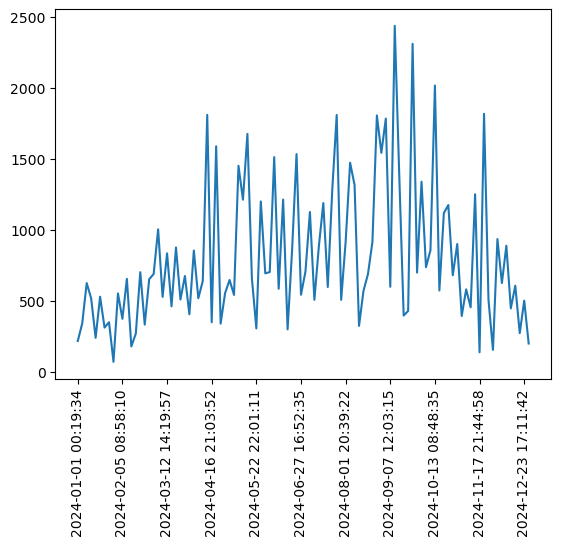

In [85]:
# On fait avec seulement un faible échantillon des dates pour que ce soit lisible (et que ça mette pas cent ans à charger)
plt.plot(df["Date"][::1000], df["Booking Value"][::1000])
plt.xticks(np.arange(0, len(df["Booking Value"][::1000]), 10), rotation=90)

On peut très vaguement distinguer une tendance où les prix évoluent en fonction du mois de l'année pour être plus élevés en été. On vérifiera cette tendance en étudiant la moyenne de Booking Value en fonction du mois (avec un groupby). La tendance semble se confirmer.

In [86]:
df["Date"] = pd.to_datetime(df["Date"])
mois = df["Date"].map(lambda x : x.month)
df.groupby(mois)["Booking Value"].mean()

Date
1      361.368427
2      507.964037
3      666.583390
4      843.041260
5      986.233894
6     1112.036826
7     1164.296212
8     1167.789683
9     1098.874707
10     987.922692
11     837.931865
12     670.762156
Name: Booking Value, dtype: float64

#### B. Carte de chaleur des corrélations

On va maintenant étudier les corrélations (au sens du coefficient de Pearson) entre les différentes variables numériques, grâce à la fonction corr() de Pandas. On affiche la matrice de corrélations avec une heatmap via la bibliothèque Seaborn. Cette matrice semble indiquer une forte corrélation entre le prix de la course et la distance parcourue, et une encore plus forte avec le temps de la course (Avg CTAT).

<Axes: >

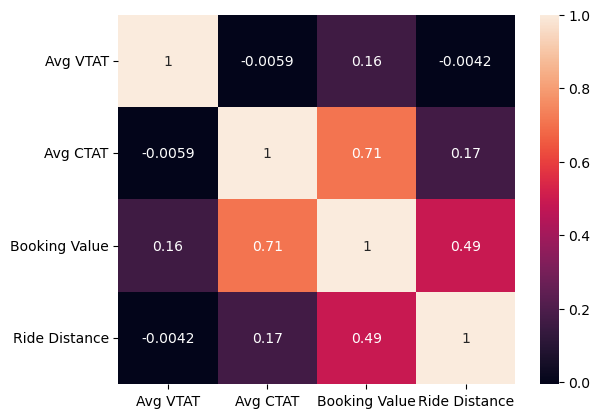

In [87]:
numerical_columns = ["Avg VTAT", "Avg CTAT", "Booking Value", "Ride Distance"]
correlation = df[numerical_columns].corr()
sns.heatmap(correlation, annot=True)

#### C. Nuage de points bivarié

On va également étudier les corrélations entre ces variables via des nuages de points pour s'en faire une idée plus précise. On utilisera pour ça la fonction pairplot() de Seaborn. On peut bel et bien voir les mêmes tendances apparaître entre la variable Booking Value et les variables Ride Distance et Avg CTAT.

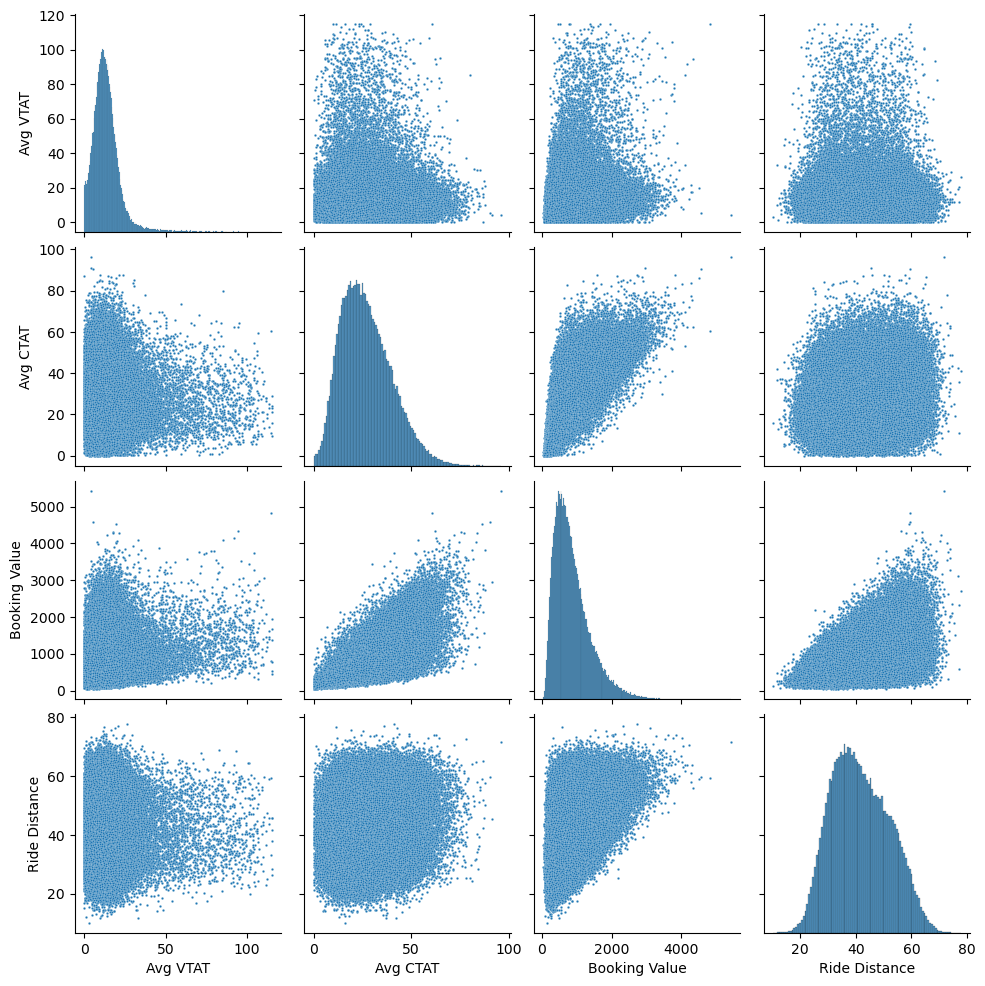

In [89]:
sns.pairplot(df[["Avg VTAT","Avg CTAT","Booking Value","Ride Distance"]], plot_kws={"s": 3})